In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Bonafide Certificate_Summer Internship_2025_IIT Dharwad.docx', 'Colab Notebooks', 'MyCV_SACHIN_YADAV_.pdf', 'Classroom', 'SachinCV.pdf', 'MyCV (1).pdf', ' datt', 'Dataset']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Dataset"))

['Testing ', 'Training ']


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
data_path = "/content/drive/MyDrive/Dataset"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_train_data = datasets.ImageFolder(f"{data_path}/Training", transform=train_transform)
test_data = datasets.ImageFolder(f"{data_path}/Testing", transform=test_transform)

train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size

train_data, val_data = random_split(full_train_data, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
class CNN_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torchvision.models.resnet50(weights="DEFAULT")
        self.model.fc = nn.Identity()

    def forward(self, x):
        return self.model(x)

In [ ]:
class ViT_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torchvision.models.vit_b_16(weights="DEFAULT")
        self.model.heads = nn.Identity()

    def forward(self, x):
        return self.model(x)

In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, cnn_dim=2048, vit_dim=768, hidden_dim=512):
        super().__init__()

        self.query = nn.Linear(vit_dim, hidden_dim)
        self.key = nn.Linear(cnn_dim, hidden_dim)
        self.value = nn.Linear(cnn_dim, hidden_dim)

        self.softmax = nn.Softmax(dim=-1)
        self.fc = nn.Linear(hidden_dim + vit_dim, hidden_dim)

    def forward(self, cnn_feat, vit_feat):
        Q = self.query(vit_feat)
        K = self.key(cnn_feat)
        V = self.value(cnn_feat)

        Q = Q.unsqueeze(1)
        K = K.unsqueeze(1)
        V = V.unsqueeze(1)

        attention = self.softmax(torch.bmm(Q, K.transpose(1,2)) / (Q.size(-1) ** 0.5))
        Z = torch.bmm(attention, V).squeeze(1)

        fused = torch.cat((vit_feat, Z), dim=1)
        return self.fc(fused)

In [ ]:
class CAFNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.cnn = CNN_Backbone()
        self.vit = ViT_Backbone()
        self.fusion = CrossAttentionFusion()

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)

        fused = self.fusion(cnn_feat, vit_feat)
        return self.classifier(fused)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CAFNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 137MB/s]


In [ ]:
import os
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"

In [ ]:
epochs = 20

train_losses = []
train_acc = []
val_acc = []

for epoch in range(epochs):

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    scheduler.step()

    train_losses.append(total_loss)
    train_accuracy = 100 * correct / total
    train_acc.append(train_accuracy)

    model.eval()
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Train={train_accuracy:.2f}%, Val={val_accuracy:.2f}%")

    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict()
    }, checkpoint_path)

Epoch 1: Loss=44.4506, Train=86.25%, Val=91.37%
Epoch 2: Loss=16.1831, Train=95.30%, Val=94.28%
Epoch 3: Loss=10.0373, Train=96.96%, Val=93.97%
Epoch 4: Loss=10.1126, Train=96.98%, Val=96.67%
Epoch 5: Loss=7.8105, Train=97.74%, Val=97.71%
Epoch 6: Loss=6.8335, Train=98.28%, Val=97.51%
Epoch 7: Loss=7.1723, Train=98.08%, Val=95.11%
Epoch 8: Loss=5.4386, Train=98.34%, Val=96.78%
Epoch 9: Loss=4.6897, Train=98.70%, Val=97.92%
Epoch 10: Loss=6.0596, Train=98.47%, Val=96.88%
Epoch 11: Loss=2.8243, Train=99.19%, Val=98.23%
Epoch 12: Loss=1.1227, Train=99.77%, Val=98.44%
Epoch 13: Loss=1.2193, Train=99.66%, Val=98.23%
Epoch 14: Loss=1.0863, Train=99.66%, Val=98.54%
Epoch 15: Loss=0.8578, Train=99.74%, Val=98.75%
Epoch 16: Loss=0.8049, Train=99.69%, Val=98.75%
Epoch 17: Loss=0.8993, Train=99.79%, Val=98.13%
Epoch 18: Loss=0.5879, Train=99.79%, Val=98.65%
Epoch 19: Loss=0.6421, Train=99.82%, Val=98.44%
Epoch 20: Loss=0.5510, Train=99.84%, Val=98.54%


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/final_model.pth")

In [ ]:
model.eval()
correct, total = 0, 0

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 95.31%


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall:", recall_score(all_labels, all_preds, average='weighted'))
print("F1-score:", f1_score(all_labels, all_preds, average='weighted'))

Precision: 0.9567240567308137
Recall: 0.953125
F1-score: 0.9520858257771875


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91       400
           1       0.90      0.99      0.94       400
           2       0.94      1.00      0.97       400
           3       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



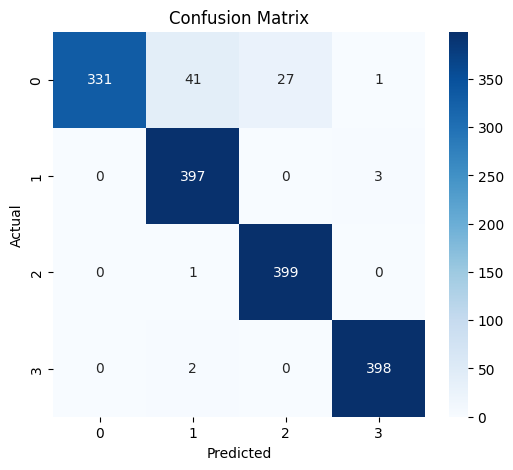

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

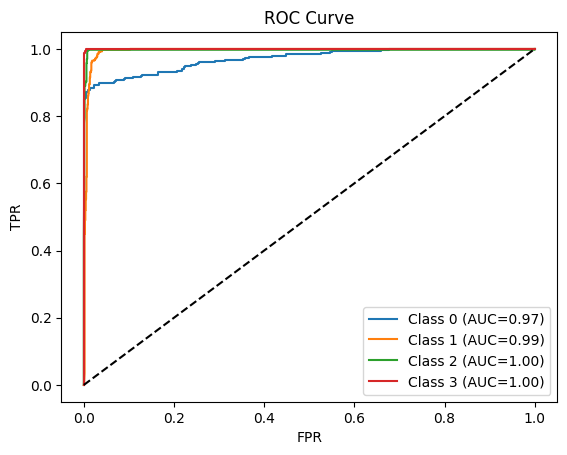

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = len(set(all_labels))

y_true = label_binarize(all_labels, classes=list(range(classes)))
y_score = np.array(all_probs)

plt.figure()

for i in range(classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

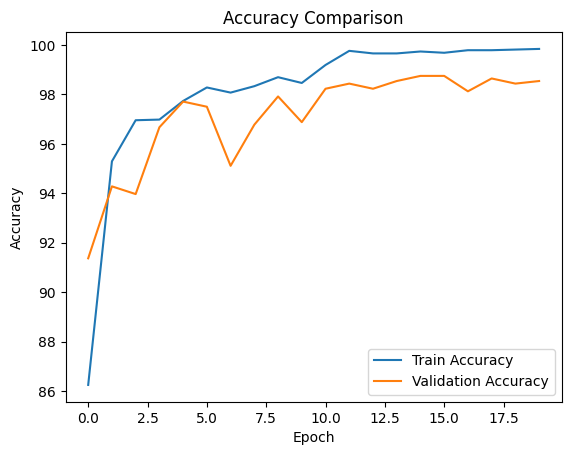

In [ ]:
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

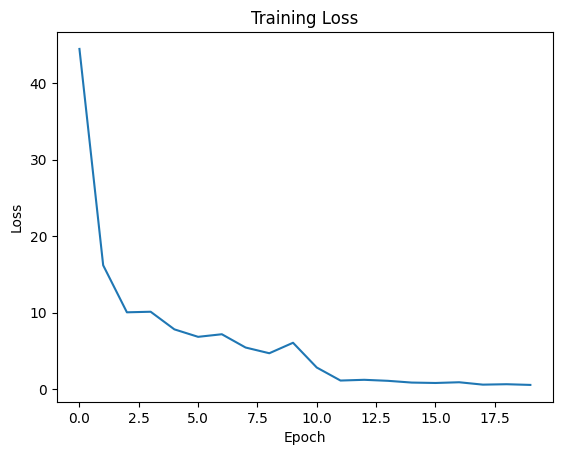

In [ ]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
for i in range(5):
    prob = all_probs[i]
    confidence = max(prob)
    print(f"Sample {i}: Confidence = {confidence:.2f}")

Sample 0: Confidence = 0.87
Sample 1: Confidence = 1.00
Sample 2: Confidence = 1.00
Sample 3: Confidence = 1.00
Sample 4: Confidence = 0.45


Enter image path: /content/Midline Glioma (Article).jpg


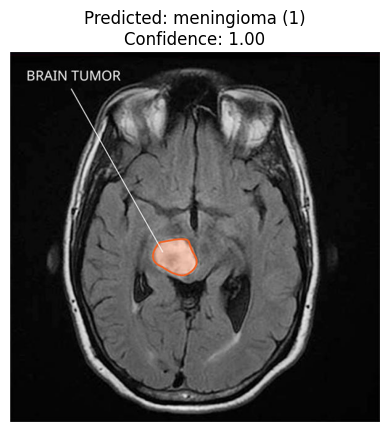

🔍 Prediction Details:
glioma (1): 0.0000
meningioma (1): 0.9980
notumor (1): 0.0013
pituitary (1): 0.0007


In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

# Load model
model = CAFNet().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/final_model.pth"))
model.eval()

# Class names
class_names = full_train_data.classes

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Take input
img_path = input("Enter image path: ")

# Load image
image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = probs.argmax(dim=1).item()
    confidence = probs[0][pred].item()

# Show image with details
plt.imshow(image)
plt.title(f"Predicted: {class_names[pred]}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

# Print detailed output
print("🔍 Prediction Details:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {probs[0][i].item():.4f}")